# Uplift Model Evaluation

This notebook evaluates uplift model performance using uplift and Qini curves.

Uplift curves measure additional conversions attributable to treatment over control across ranking quantiles.

Qini curve visualizes cumulative incremental gains.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from src.uplift_t_learner import TLearner
from src.uplift_evaluation import qini_curve
import matplotlib.pyplot as plt

df = pd.read_csv("../data/simulated_campaign_data.csv")

X = df[["age","income","tenure","usage"]]
treatment = df["treatment"]
y = df["outcome"]

tlearner = TLearner()
tlearner.fit(X, treatment, y)

uplift_scores = tlearner.predict_uplift(X)
df["uplift_score"] = uplift_scores

## Uplift and Qini Curves

We sort customers by predicted uplift scores.

High uplift implies greater estimated incremental impact.

Uplift curve plots cumulative incremental response against percentage of population targeted.

Qini curve adjusts for control response scaling.

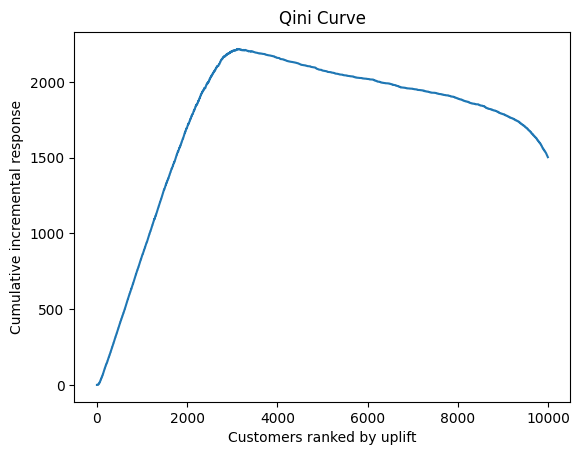

In [2]:
# Sort by uplift
df_sorted = df.sort_values("uplift_score", ascending=False)

# Compute cumulative outcomes
cum_uplift = qini_curve(df["outcome"].values, df["treatment"].values, df["uplift_score"].values)

plt.plot(cum_uplift)
plt.title("Qini Curve")
plt.xlabel("Customers ranked by uplift")
plt.ylabel("Cumulative incremental response")
plt.show()

### Interpretation

The Qini curve reveals the cumulative incremental impact attributable to treatment across the ranking.

If the curve rises early, the model effectively identifies high-impact customers.

Area under this curve (AUUC) quantifies ranking quality: higher AUUC implies better uplift model.

This evaluation differentiates good causal ranking from naive profit numbers.